# Домашнее задание 3

Визуализация данных о пассажирах Титаника (`train.csv`).

Для графиков использую `matplotlib` и `seaborn`, для интерактивного sunburst — `plotly`. Цвета категорий задаю один раз, чтобы на всех графиках одна и та же категория (класс, пол, исход) была одного цвета.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px
import seaborn as sns

sns.set_theme(style="whitegrid")

BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"

SEX_LABELS = {"male": "Мужчины", "female": "Женщины"}
SURVIVED_LABELS = {0: "Не выжил", 1: "Выжил"}
CLASS_LABELS = {1: "1 класс", 2: "2 класс", 3: "3 класс"}

SEX_COLORS = {"Мужчины": BLUE, "Женщины": ORANGE}
SURVIVED_COLORS = {"Не выжил": BLUE, "Выжил": ORANGE}
CLASS_COLORS = {"1 класс": BLUE, "2 класс": ORANGE, "3 класс": AQUA}

## Задание 1. Чтение датасета (1 балл)

Помимо исходных данных, добавляю столбцы с русскими подписями для пола, исхода и класса. Они нужны только для подписей на графиках.

In [2]:
df = pd.read_csv("train.csv")

df["SexLabel"] = df["Sex"].map(SEX_LABELS)
df["SurvivedLabel"] = df["Survived"].map(SURVIVED_LABELS)
df["ClassLabel"] = df["Pclass"].map(CLASS_LABELS)

print(df.shape)
df.head()

(891, 15)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,SexLabel,SurvivedLabel,ClassLabel
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Мужчины,Не выжил,3 класс
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Женщины,Выжил,1 класс
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Женщины,Выжил,3 класс
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Женщины,Выжил,1 класс
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Мужчины,Не выжил,3 класс


## Задание 2. Распределение признаков Survived, Pclass, Age, Sex, Parch (2 балла)

Для категориальных и дискретных признаков (`Survived`, `Pclass`, `Sex`, `Parch`) строю столбчатые диаграммы количества. Для непрерывного `Age` строю гистограмму с кривой плотности и отмечаю на ней среднее и медиану.

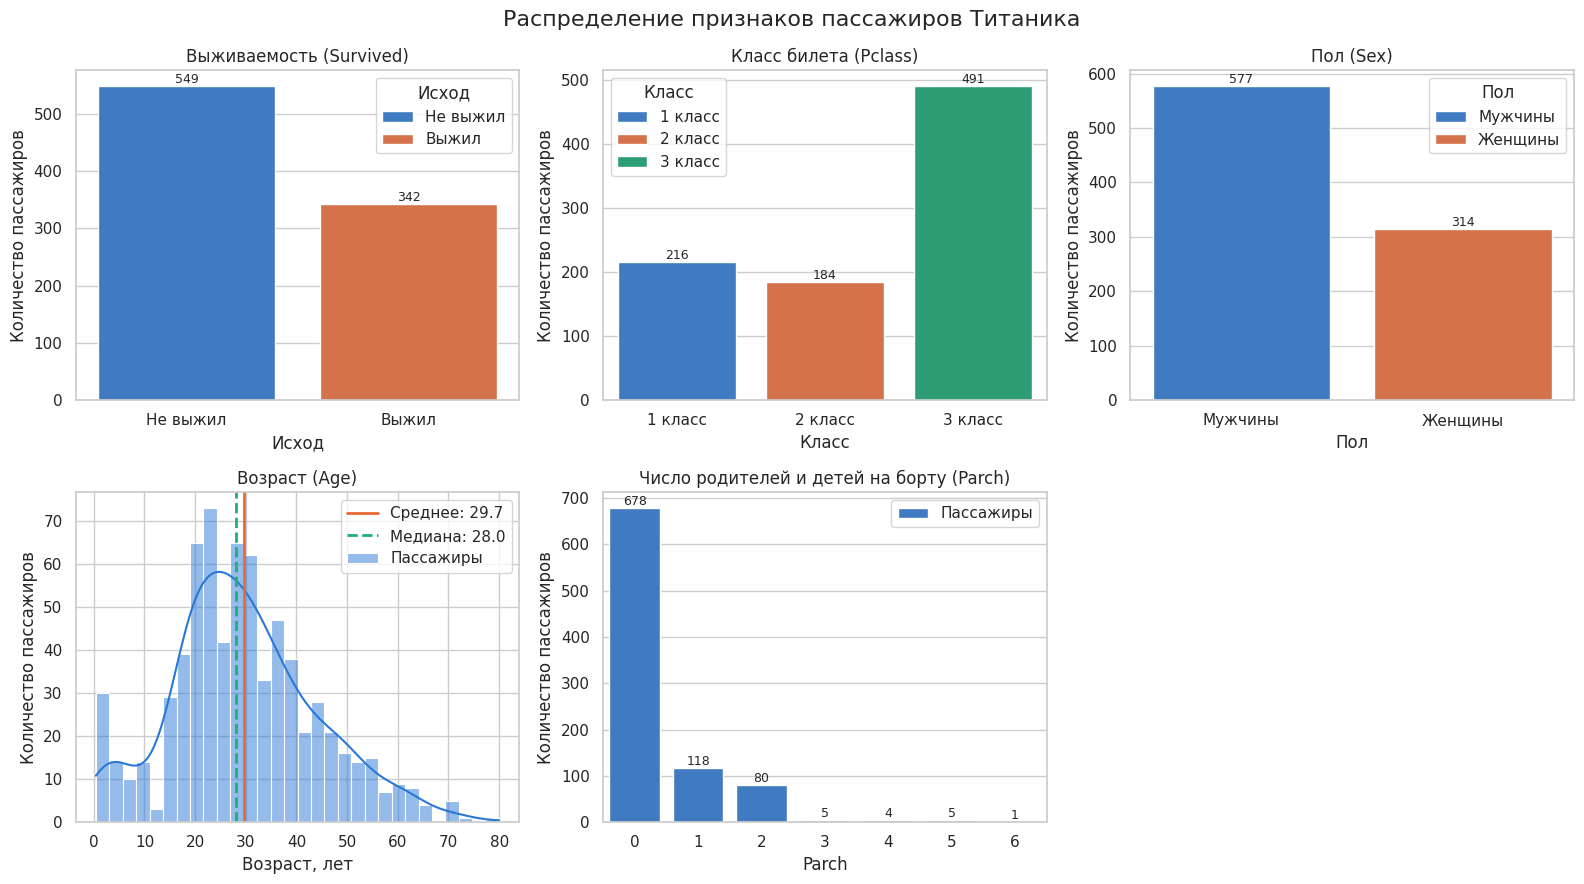

In [3]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

sns.countplot(data=df, x="SurvivedLabel", hue="SurvivedLabel", order=list(SURVIVED_COLORS), hue_order=list(SURVIVED_COLORS),
              palette=SURVIVED_COLORS, legend=True, ax=axes[0, 0])
axes[0, 0].set(title="Выживаемость (Survived)", xlabel="Исход", ylabel="Количество пассажиров")
axes[0, 0].legend(title="Исход")

sns.countplot(data=df, x="ClassLabel", hue="ClassLabel", order=list(CLASS_COLORS), hue_order=list(CLASS_COLORS),
              palette=CLASS_COLORS, legend=True, ax=axes[0, 1])
axes[0, 1].set(title="Класс билета (Pclass)", xlabel="Класс", ylabel="Количество пассажиров")
axes[0, 1].legend(title="Класс")

sns.countplot(data=df, x="SexLabel", hue="SexLabel", order=list(SEX_COLORS), hue_order=list(SEX_COLORS),
              palette=SEX_COLORS, legend=True, ax=axes[0, 2])
axes[0, 2].set(title="Пол (Sex)", xlabel="Пол", ylabel="Количество пассажиров")
axes[0, 2].legend(title="Пол")

sns.histplot(data=df, x="Age", bins=30, kde=True, color=BLUE, label="Пассажиры", ax=axes[1, 0])
axes[1, 0].axvline(df["Age"].mean(), color=ORANGE, linewidth=2, label=f"Среднее: {df['Age'].mean():.1f}")
axes[1, 0].axvline(df["Age"].median(), color=AQUA, linewidth=2, linestyle="--",
                   label=f"Медиана: {df['Age'].median():.1f}")
axes[1, 0].set(title="Возраст (Age)", xlabel="Возраст, лет", ylabel="Количество пассажиров")
axes[1, 0].legend()

sns.countplot(data=df, x="Parch", color=BLUE, label="Пассажиры", ax=axes[1, 1])
axes[1, 1].set(title="Число родителей и детей на борту (Parch)",
               xlabel="Parch", ylabel="Количество пассажиров")
axes[1, 1].legend()

axes[1, 2].axis("off")

for ax in axes.flat[:5]:
    for container in ax.containers:
        if ax is not axes[1, 0]:
            ax.bar_label(container, fontsize=9)

fig.suptitle("Распределение признаков пассажиров Титаника", fontsize=16)
fig.tight_layout()
plt.show()

In [4]:
print("Пропусков в Age:", df["Age"].isna().sum())
print(df["Survived"].value_counts(normalize=True).round(3))
print(df["Pclass"].value_counts(normalize=True).sort_index().round(3))
print(df["Parch"].value_counts().sort_index())

Пропусков в Age: 177
Survived
0    0.616
1    0.384
Name: proportion, dtype: float64
Pclass
1    0.242
2    0.207
3    0.551
Name: proportion, dtype: float64
Parch
0    678
1    118
2     80
3      5
4      4
5      5
6      1
Name: count, dtype: int64


**Выводы:**

- **Survived:** не выжило больше пассажиров (62 %), чем выжило (38 %).
- **Pclass:** больше половины пассажиров (55 %) ехали третьим классом. Первым и вторым классом ехало примерно поровну (24 % и 21 %).
- **Sex:** мужчин почти вдвое больше, чем женщин (577 и 314).
- **Age:** основная масса пассажиров в возрасте 20–40 лет, распределение немного скошено вправо: есть небольшой хвост пожилых пассажиров. Среднее (29.7) чуть выше медианы (28). Отдельно виден небольшой пик у детей до 5 лет. Возраст неизвестен у 177 пассажиров, на гистограмме их нет.
- **Parch:** у большинства пассажиров (678) на борту не было ни родителей, ни детей. Значения больше 2 встречаются единично.

## Задание 3. Boxplot для столбца Age (2 балла)

Помимо медианы, на графике показываю среднее значение (маркер) и подписываю легенду.

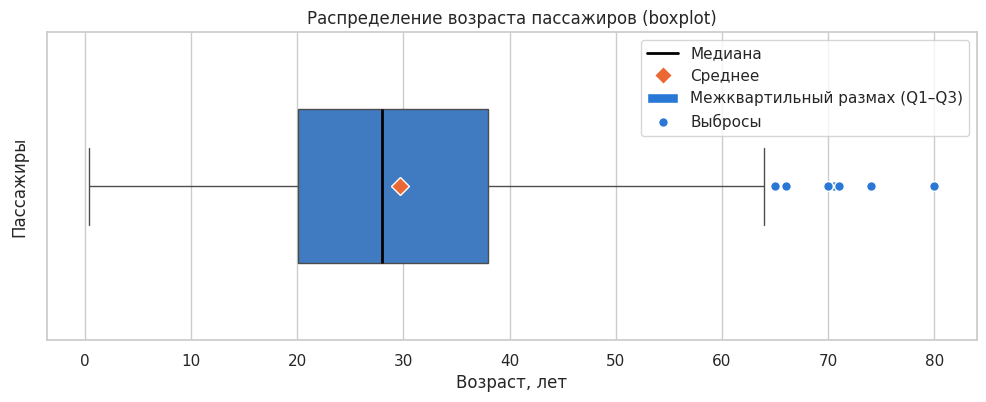

In [5]:
fig, ax = plt.subplots(figsize=(12, 4))

sns.boxplot(x=df["Age"], color=BLUE, showmeans=True, width=0.5,
            medianprops={"color": "black", "linewidth": 2},
            meanprops={"marker": "D", "markerfacecolor": ORANGE, "markeredgecolor": "white", "markersize": 9},
            flierprops={"marker": "o", "markerfacecolor": BLUE, "markeredgecolor": "white", "markersize": 7},
            ax=ax)

legend_handles = [
    plt.Line2D([], [], color="black", linewidth=2, label="Медиана"),
    plt.Line2D([], [], marker="D", linestyle="", markerfacecolor=ORANGE, markeredgecolor="white",
               markersize=9, label="Среднее"),
    plt.Rectangle((0, 0), 1, 1, facecolor=BLUE, label="Межквартильный размах (Q1–Q3)"),
    plt.Line2D([], [], marker="o", linestyle="", markerfacecolor=BLUE, markeredgecolor="white",
               markersize=7, label="Выбросы"),
]
ax.legend(handles=legend_handles, loc="upper right")
ax.set(title="Распределение возраста пассажиров (boxplot)", xlabel="Возраст, лет", ylabel="Пассажиры")
plt.show()

Для интерпретации считаю квартили, границы «усов» и количество выбросов. Усы в boxplot доходят до самых дальних точек в пределах 1.5 × IQR от квартилей, всё, что дальше, — выбросы.

In [6]:
age = df["Age"].dropna()
q1, median, q3 = age.quantile([0.25, 0.5, 0.75])
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr
lower_bound = q1 - 1.5 * iqr

print(f"Q1 = {q1}, медиана = {median}, Q3 = {q3}, IQR = {iqr}")
print(f"Среднее = {age.mean():.1f}, минимум = {age.min()}, максимум = {age.max()}")
print(f"Границы усов: от {max(lower_bound, age.min())} до {upper_bound}")
print("Выбросы:", sorted(age[age > upper_bound].tolist()))

Q1 = 20.125, медиана = 28.0, Q3 = 38.0, IQR = 17.875
Среднее = 29.7, минимум = 0.42, максимум = 80.0
Границы усов: от 0.42 до 64.8125
Выбросы: [65.0, 65.0, 65.0, 66.0, 70.0, 70.0, 70.5, 71.0, 71.0, 74.0, 80.0]


## Задание 4. Интерпретация boxplot (2 балла)

- **Центр распределения.** Медианный возраст пассажира 28 лет. Половина пассажиров с известным возрастом находится в диапазоне от 20 до 38 лет (межквартильный размах около 18 лет).
- **Асимметрия.** Правый ус длиннее левого, а среднее (29.7) правее медианы. Значит, распределение скошено вправо: молодых и средних по возрасту пассажиров много, а пожилых мало, но они «растягивают» распределение.
- **Нижняя граница.** Левый ус доходит до минимального возраста (0.42 года, то есть младенцы): формально нижняя граница 1.5 × IQR отрицательная, поэтому выбросов снизу нет.
- **Выбросы.** Верхняя граница усов около 64.8 лет. Выше неё 11 пассажиров в возрасте от 65 до 80 лет. Это не ошибки в данных, а реальные пожилые пассажиры, просто их мало по сравнению с остальными.
- **Ограничение.** График построен только по 714 пассажирам: у 177 возраст неизвестен.

## Задание 5. Pie chart для Survived и Pclass (2 балла)

Доли в процентах подписываю параметром `autopct`.

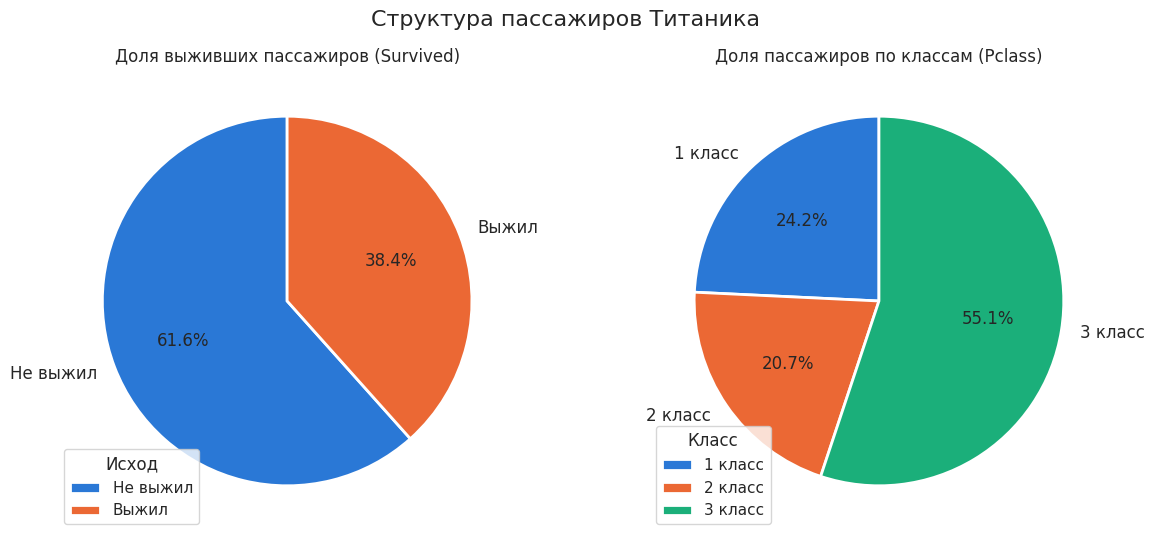

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

survived_counts = df["SurvivedLabel"].value_counts().reindex(["Не выжил", "Выжил"])
axes[0].pie(survived_counts, labels=survived_counts.index, autopct="%1.1f%%", startangle=90,
            colors=[SURVIVED_COLORS[k] for k in survived_counts.index],
            wedgeprops={"edgecolor": "white", "linewidth": 2}, textprops={"fontsize": 12})
axes[0].set_title("Доля выживших пассажиров (Survived)")
axes[0].legend(title="Исход", loc="lower left")

class_counts = df["ClassLabel"].value_counts().reindex(list(CLASS_COLORS))
axes[1].pie(class_counts, labels=class_counts.index, autopct="%1.1f%%", startangle=90,
            colors=[CLASS_COLORS[k] for k in class_counts.index],
            wedgeprops={"edgecolor": "white", "linewidth": 2}, textprops={"fontsize": 12})
axes[1].set_title("Доля пассажиров по классам (Pclass)")
axes[1].legend(title="Класс", loc="lower left")

fig.suptitle("Структура пассажиров Титаника", fontsize=16)
plt.show()

**Вывод:** выжило только 38.4 % пассажиров. Больше половины пассажиров (55.1 %) — третий класс, первый и второй классы составляют 24.2 % и 20.7 %.

## Задание 6. Pairplot для числовых переменных (2 балла)

Беру все числовые столбцы датасета. Точки раскрашиваю по исходу (выжил / не выжил), чтобы было видно, как признаки связаны с выживаемостью. `PassengerId` — просто порядковый номер, поэтому никакой связи с другими признаками у него не ожидается.

In [8]:
numeric_cols = df.select_dtypes("number").columns.tolist()
print(numeric_cols)

['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']


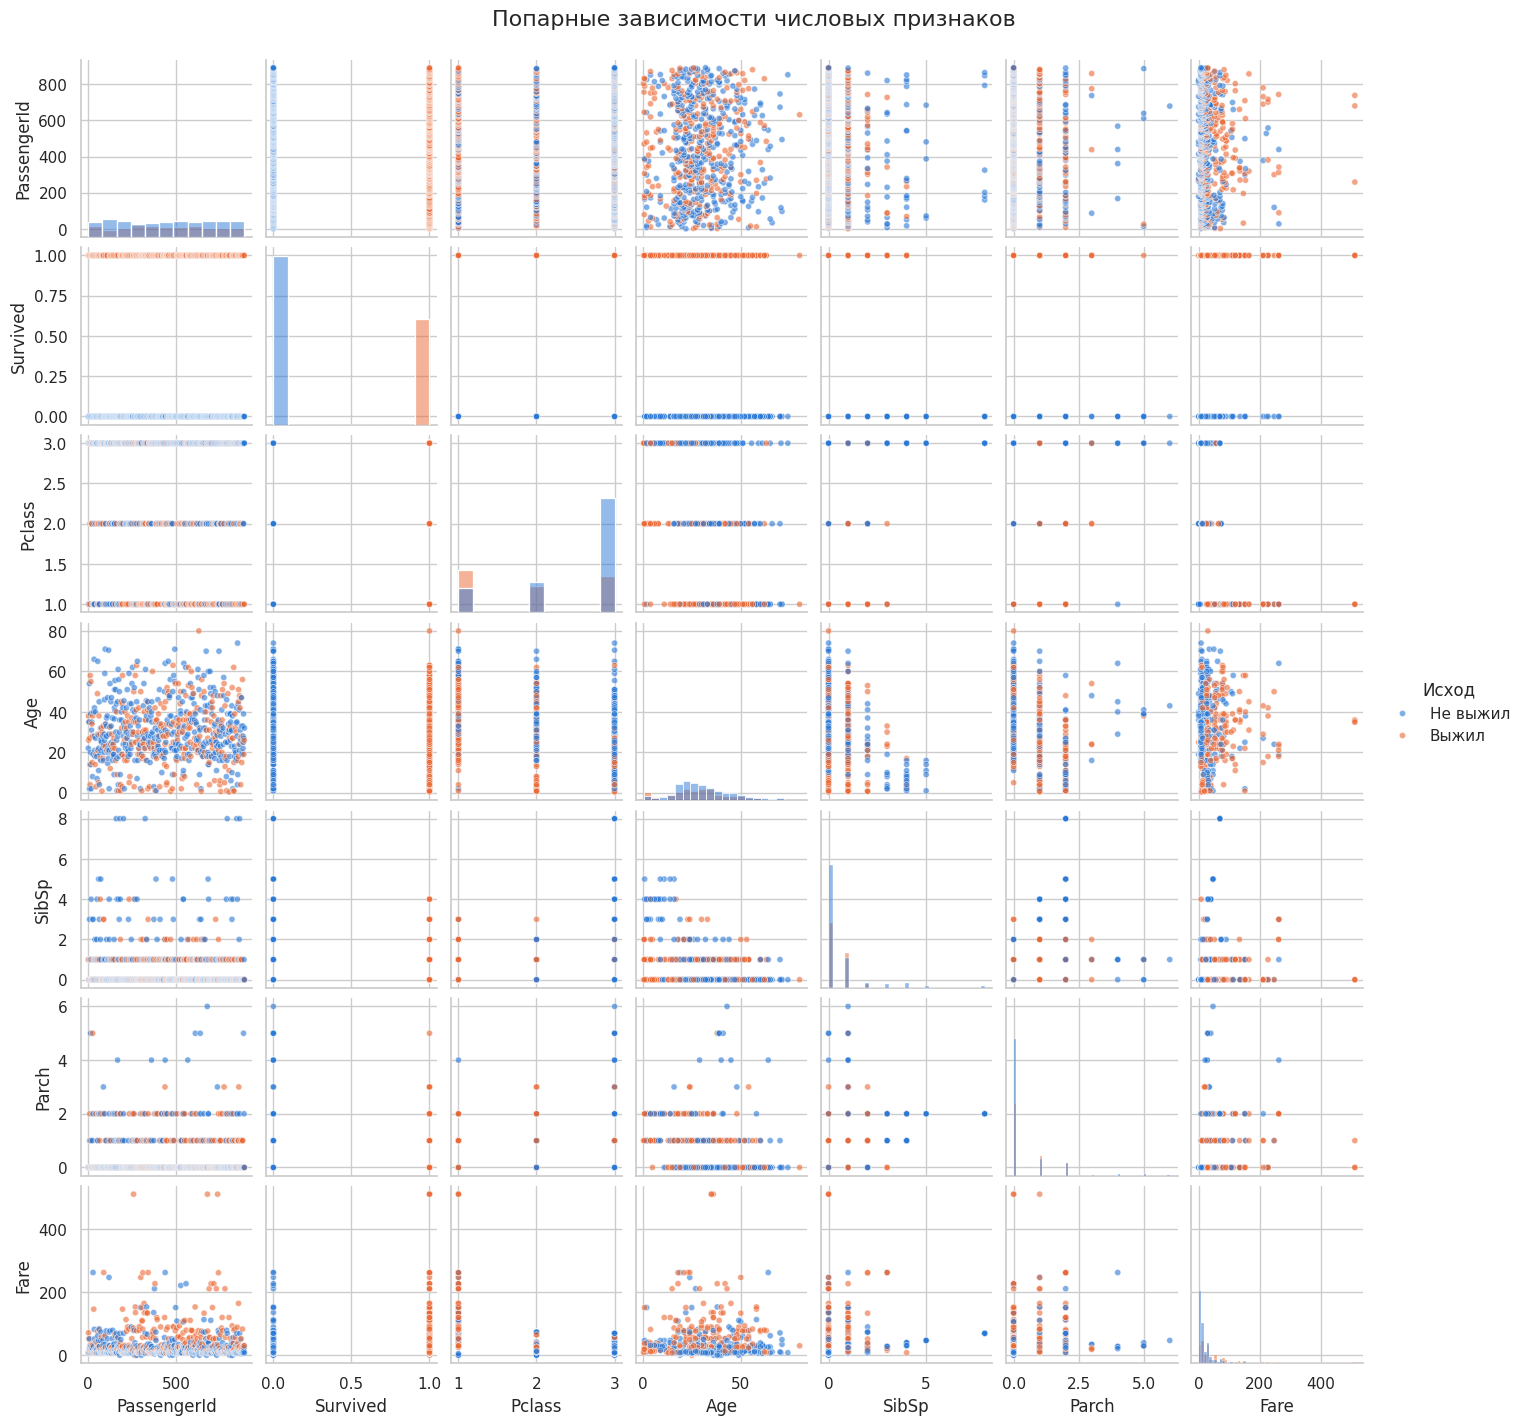

In [9]:
g = sns.pairplot(df, vars=numeric_cols, hue="SurvivedLabel", hue_order=list(SURVIVED_COLORS),
                 palette=SURVIVED_COLORS, diag_kind="hist", height=2,
                 plot_kws={"alpha": 0.6, "s": 20, "edgecolor": "white", "linewidth": 0.5})
g.legend.set_title("Исход")
g.figure.suptitle("Попарные зависимости числовых признаков", fontsize=16, y=1.02)
plt.show()

Проверяю численно то, что видно на графике: выживаемость по классам, стоимость билетов вне первого класса и пассажиров с большим числом братьев и сестёр.

In [10]:
print(df.groupby("Pclass")["Survived"].mean().round(2))
print("Максимальная цена билета во 2 и 3 классах:", df.loc[df["Pclass"] > 1, "Fare"].max())

many_siblings = df[df["SibSp"] >= 3]
print(f"SibSp >= 3: {len(many_siblings)} пассажиров, медианный возраст {many_siblings['Age'].median()}, "
      f"выжило {many_siblings['Survived'].mean():.1%}")

Pclass
1    0.63
2    0.47
3    0.24
Name: Survived, dtype: float64
Максимальная цена билета во 2 и 3 классах: 73.5
SibSp >= 3: 46 пассажиров, медианный возраст 8.0, выжило 15.2%


**Вывод:**

- Признаки `Survived`, `Pclass`, `SibSp` и `Parch` дискретные, поэтому на их диаграммах точки выстраиваются в линии.
- На гистограмме `Pclass` видно, что в третьем классе погибших намного больше, чем выживших (выжило 24 %), а в первом, наоборот, выживших больше (63 %).
- На графиках с `Fare` среди пассажиров с дорогими билетами заметно больше выживших. Все билеты дороже 73.5 относятся к первому классу.
- Пассажиры с `SibSp` ≥ 3 — это в основном дети из многодетных семей (медианный возраст 8 лет), и выжило из них только 15 %.
- На графике `Age` — `SibSp` видно, что чем больше братьев и сестёр, тем моложе пассажир.
- `PassengerId` не связан ни с одним признаком: точки распределены равномерно.

## Задание 7. Violin plot возраста по полу (2 балла)

Внутри «скрипок» показываю квартили пунктиром.

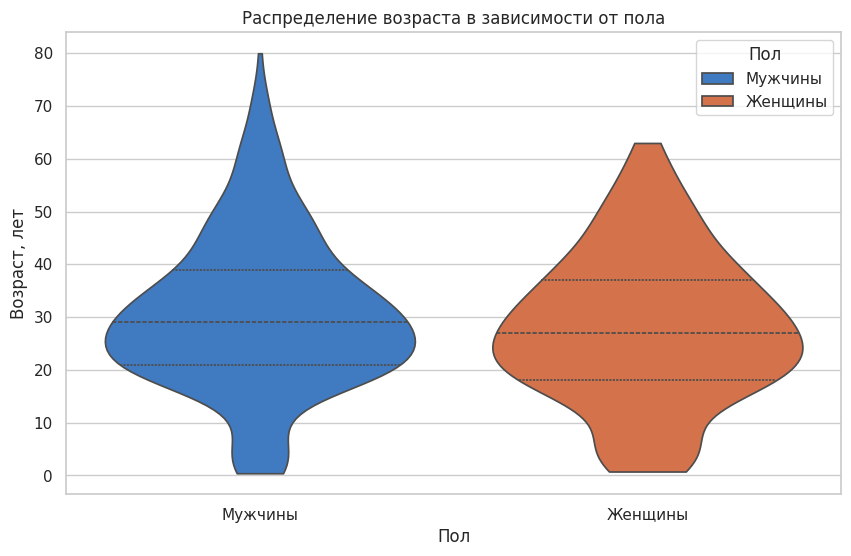

In [11]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.violinplot(data=df, x="SexLabel", y="Age", hue="SexLabel", order=list(SEX_COLORS), hue_order=list(SEX_COLORS),
               palette=SEX_COLORS, inner="quart", cut=0, legend=True, ax=ax)
ax.set(title="Распределение возраста в зависимости от пола", xlabel="Пол", ylabel="Возраст, лет")
ax.legend(title="Пол")
plt.show()

In [12]:
df.groupby("SexLabel")["Age"].describe().round(1)

,count,mean,std,min,25%,50%,75%,max
SexLabel,,,,,,,,
Женщины,261.0,27.9,14.1,0.8,18.0,27.0,37.0,63.0
Мужчины,453.0,30.7,14.7,0.4,21.0,29.0,39.0,80.0


**Вывод:** формы распределений у мужчин и женщин похожи: основная масса в диапазоне 20–40 лет и небольшой «наплыв» детей. Но женщины в среднем немного моложе: медиана 27 лет против 29 у мужчин. У мужчин распределение шире и длиннее вверх: самый пожилой пассажир — мужчина 80 лет, а самой старшей женщине 63 года.

## Задание 8. Heatmap корреляционной матрицы (2 балла)

Считаю коэффициенты корреляции Пирсона между числовыми признаками. Шкала цветов симметрична относительно нуля: синий цвет — отрицательная связь, красный — положительная.

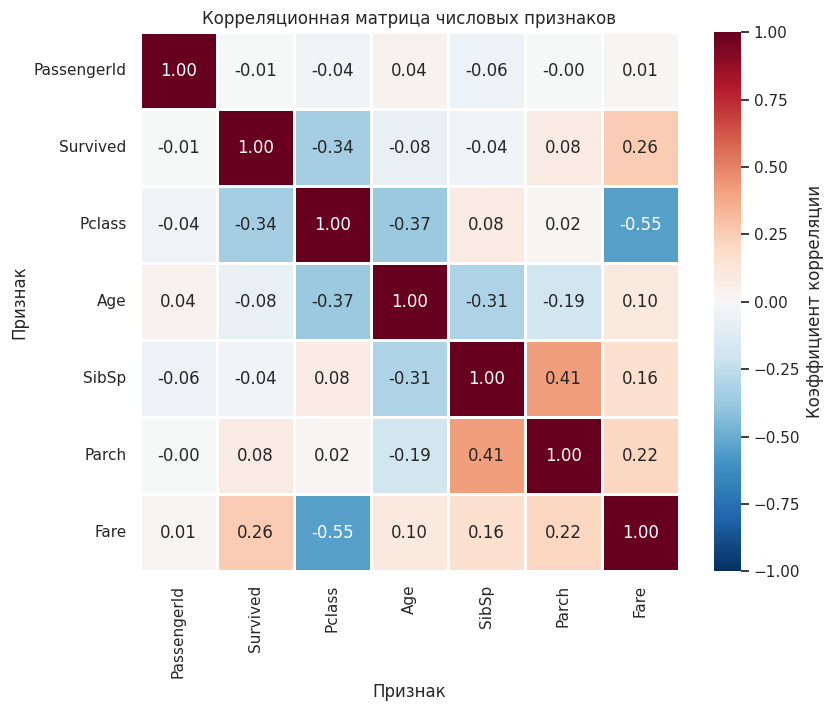

In [13]:
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, center=0,
            square=True, linewidths=1, linecolor="white",
            cbar_kws={"label": "Коэффициент корреляции"}, ax=ax)
ax.set(title="Корреляционная матрица числовых признаков", xlabel="Признак", ylabel="Признак")
plt.show()

**Вывод:**

- Самая сильная связь — между `Pclass` и `Fare` (−0.55): чем выше класс (меньше номер), тем дороже билет.
- С выживаемостью сильнее всего связаны `Pclass` (−0.34) и `Fare` (0.26): пассажиры высоких классов с дорогими билетами выживали чаще.
- `Age` отрицательно связан с `Pclass` (−0.37): в первом классе пассажиры в среднем старше.
- `SibSp` и `Parch` связаны между собой (0.41), так как оба отражают путешествие с семьёй.
- `PassengerId` ни с чем не коррелирует, это ожидаемо для порядкового номера.

Корреляция Пирсона улавливает только линейную связь, а пол в матрицу не попал, так как это текстовый признак.

## Задание 9. Интерактивный sunburst plot (3 балла)

Считаю количество пассажиров в каждой паре «класс — пол». Внутреннее кольцо — классы (их размер равен сумме по полу), внешнее — мужчины и женщины внутри класса. При наведении показывается количество и доля, а по клику на класс можно его развернуть.

In [14]:
class_sex_counts = df.groupby(["ClassLabel", "SexLabel"]).size().reset_index(name="Пассажиров")
class_sex_counts

,ClassLabel,SexLabel,Пассажиров
0,1 класс,Женщины,94
1,1 класс,Мужчины,122
2,2 класс,Женщины,76
3,2 класс,Мужчины,108
4,3 класс,Женщины,144
5,3 класс,Мужчины,347


In [15]:
fig = px.sunburst(
    class_sex_counts,
    path=["ClassLabel", "SexLabel"],
    values="Пассажиров",
    color="ClassLabel",
    color_discrete_map=CLASS_COLORS,
    title="Пассажиры Титаника по классам и полу",
    labels={"ClassLabel": "Класс", "SexLabel": "Пол", "Пассажиров": "Пассажиров"},
)
fig.update_traces(
    textinfo="label+value+percent parent",
    hovertemplate="<b>%{label}</b><br>Пассажиров: %{value}<br>Доля в родительском уровне: %{percentParent:.1%}<extra></extra>",
    marker={"line": {"color": "white", "width": 2}},
)
fig.update_layout(width=700, height=700)
fig.show()

**Вывод:** третий класс — самый многочисленный (491 пассажир), и в нём доля мужчин максимальная: 347 человек, около 71 %. В первом и втором классах мужчин тоже больше, но разрыв меньше: 122 против 94 и 108 против 76.

У sunburst нет осей, а легенду заменяют подписи на секторах: у каждого сектора указаны название, количество и доля от родительского уровня.